# ModHav Synthetic Dataset v2

OPTION 3

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import Havlicek_synthetic_dataset, ModHav_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.training_candidate import train_candidate_optuna_angles
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

In [2]:
# ── 1. Data ────────────────────────────────────────────────────────────────
X, y = ModHav_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

RESULTS_DIR = 'Results/ModHav Synthetic v2'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

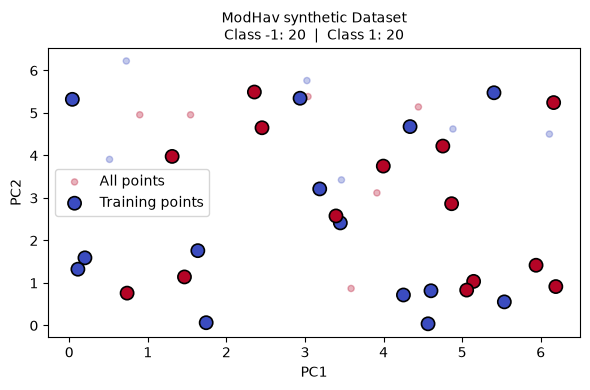

In [3]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('ModHav synthetic', X, y, X_train, y_train, 'yes')

In [4]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric', 'haar', 'angles'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    ExperimentConfig(
        name             = 'optuna_angles',
        optimizer        = 'optuna',
        variant          = 'angles',
        subset_method    = 'none',
        optimizer_kwargs = {'stage1_trials': 100, 'stage2_trials': 100},
    ),
]

In [5]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }


Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_angles  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_angles'
Loading cached SVM results for 'optuna_angles'


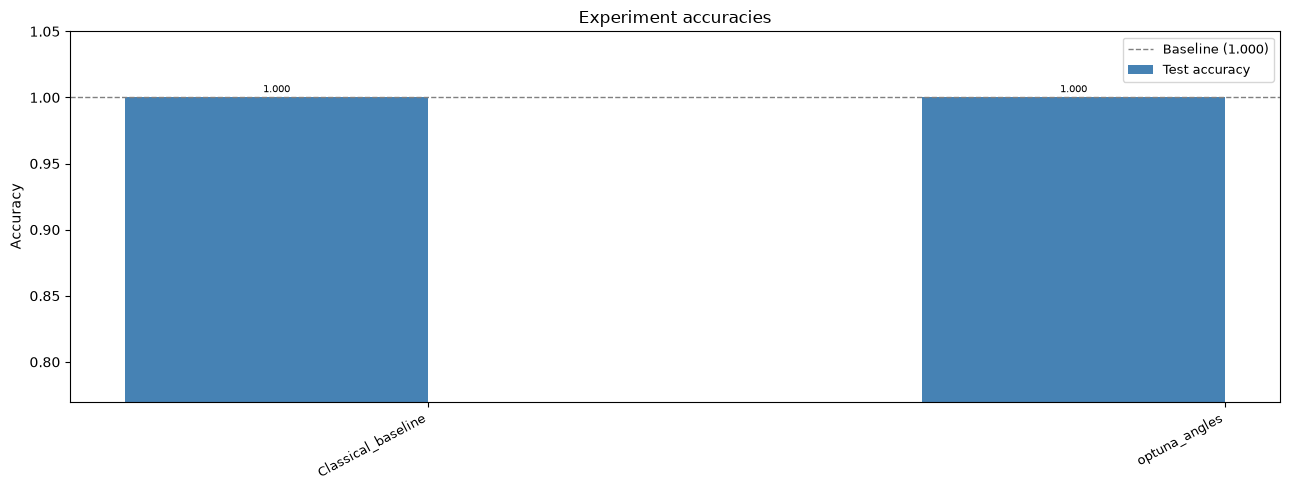

Saved → Results/ModHav Synthetic v2/accuracy_comparison.png


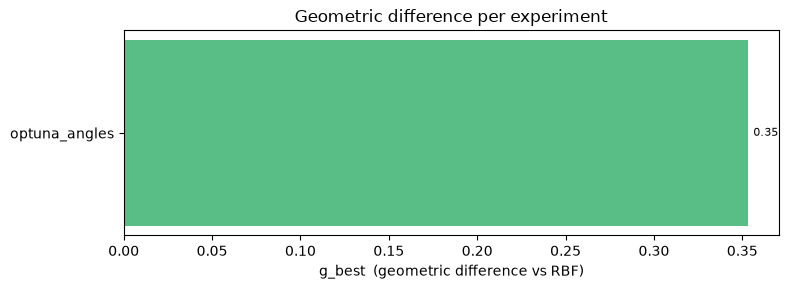

Saved → Results/ModHav Synthetic v2/g_best_comparison.png


In [6]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)

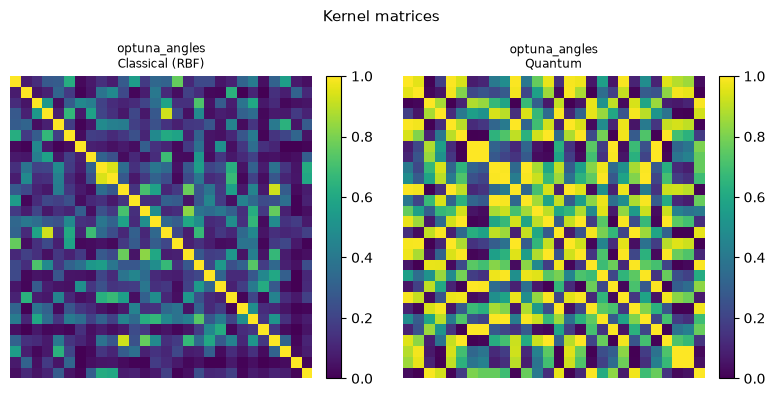

Saved → Results/ModHav Synthetic v2/kernel_heatmaps.png


In [7]:
plot_kernel_heatmaps(summary)